# Klasifikasi Pola Batik Megamendung dan Parang Menggunakan Convolutional Neural Networks

## Anggota Kelompok
1. Zakiyah Hasanah (2305274)
2. Putra Hadiyanto Nugroho (2308163)
3. Hafsah Hamidah (2311474)
4. Natasha Adinda Cantika (2312120)


## Pendahuluan
Proyek ini mengimplementasikan sistem klasifikasi otomatis untuk membedakan dua jenis pola batik tradisional Indonesia, yaitu Megamendung dan Parang, menggunakan teknik deep learning dengan TensorFlow dan Keras. Dataset yang digunakan terdiri dari 1000 gambar batik dengan pembagian yang seimbang, masing-masing 500 gambar untuk setiap kategori. Setiap gambar telah diproses dan dinormalisasi ke ukuran 224 x 224 piksel untuk memastikan konsistensi input dalam model pembelajaran mesin.

Penelitian ini membandingkan empat pendekatan berbeda dalam membangun model CNN untuk mengevaluasi efektivitas berbagai teknik preprocessing dan arsitektur jaringan. Pendekatan pertama menggunakan CNN sederhana tanpa preprocessing data, kedua menerapkan CNN sederhana dengan augmentasi data, ketiga mengimplementasikan arsitektur CNN kustom dengan regularisasi, dan keempat memanfaatkan transfer learning dari model pre-trained. Perbandingan ini bertujuan untuk memahami dampak setiap teknik terhadap performa klasifikasi dan memberikan wawasan tentang praktik terbaik dalam computer vision untuk dataset dengan karakteristik khusus seperti pola batik.


### 3 Skenario Model:
1. **CNN Sederhana tanpa Preprocessing**
2. **CNN Sederhana dengan Preprocessing**
3. **Transfer Learning CNN dengan Preprocessing**

### Detail Dataset
Dataset: 1000 gambar batik (500 megamendung + 500 parang)  
Ukuran gambar: 224 x 224 px (sudah di-crop dan resize)


## 1. Import Required Libraries

Tahap persiapan ini melibatkan impor seluruh library yang diperlukan untuk implementasi sistem klasifikasi batik. TensorFlow dan Keras menjadi framework utama untuk membangun dan melatih model deep learning, sementara berbagai modul dari keras.preprocessing digunakan untuk manipulasi dan augmentasi gambar. Library aplikasi pre-trained seperti VGG16, ResNet50, dan MobileNetV2 diimpor untuk mendukung implementasi transfer learning pada model keempat.

Untuk analisis data dan visualisasi, digunakan kombinasi NumPy untuk operasi matematis pada array, Pandas untuk manipulasi data tabular, Matplotlib dan Seaborn untuk visualisasi grafis. Scikit-learn menyediakan fungsi evaluasi model seperti classification report dan confusion matrix. Konfigurasi tambahan meliputi pengaturan warning filter untuk mengabaikan peringatan yang tidak relevan dan konfigurasi style plotting untuk menghasilkan visualisasi yang konsisten dan menarik secara visual.

In [ ]:
# Import libraries untuk deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Libraries untuk data manipulation dan visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import os
import warnings
import urllib.request
import zipfile
from pathlib import Path
warnings.filterwarnings('ignore')

# Set style untuk plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Tampilkan versi TensorFlow
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU availability
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
if tf.config.list_physical_devices('GPU'):
    print("GPU will be used for training")
else:
    print("CPU will be used for training")

TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU will be used for training


## 2. Data Loading dan Exploratory Data Analysis (EDA)

Bagian ini mengimplementasikan sistem download dataset yang robust dengan multiple fallback strategy untuk memastikan keberhasilan pengunduhan data dari repository GitHub.

Proses analisis eksploratori data meliputi pemeriksaan distribusi dataset, visualisasi sample gambar dari setiap kategori, dan analisis karakteristik pixel intensity dari gambar batik. Analisis ini penting untuk memahami karakteristik data sebelum memulai proses preprocessing dan training model. Informasi yang diperoleh dari tahap ini akan membantu dalam menentukan strategi augmentasi data dan konfigurasi parameter model yang optimal.

In [ ]:
# Download dataset dari GitHub repository
def download_dataset_from_github():
    """Download dataset dari GitHub repository"""
    print("🔄 Downloading dataset dari GitHub repository...")

    # GitHub repository URLs untuk download zip
    github_repo_url = "https://github.com/kiy4h/DeepLearning_CNN/archive/refs/heads/main.zip"

    # Path untuk menyimpan dataset
    dataset_zip = "DeepLearning_CNN-main.zip"

    try:
        # Download zip file
        print("📥 Downloading zip file...")
        urllib.request.urlretrieve(github_repo_url, dataset_zip)
        print("✅ Download completed!")

        # Extract zip file
        print("📂 Extracting files...")
        with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
            zip_ref.extractall("./")

        # Clean up zip file
        os.remove(dataset_zip)

        # Check if dataset_final exists
        dataset_path = "DeepLearning_CNN-main/dataset_final"
        if os.path.exists(dataset_path):
            print(f"✅ Dataset berhasil didownload ke: {dataset_path}")
            return dataset_path
        else:
            print("❌ Dataset_final tidak ditemukan dalam repository")
            return None

    except Exception as e:
        print(f"❌ Error downloading dataset: {str(e)}")
        return None

# Download dataset
base_path = download_dataset_from_github()

🔄 Downloading dataset dari GitHub repository...
📥 Downloading zip file...
✅ Download completed!
📂 Extracting files...
✅ Dataset berhasil didownload ke: DeepLearning_CNN-main/dataset_final


In [ ]:
# Alternative: Direct download dari GitHub dengan wget (Google Colab friendly)
def download_with_wget():
    """Download menggunakan wget command (lebih reliable di Colab)"""
    print("🔄 Trying wget download method...")
    try:
        # Install wget jika belum ada
        os.system("apt-get install -y wget > /dev/null 2>&1")

        # Download dan extract
        commands = [
            "wget -q https://github.com/kiy4h/DeepLearning_CNN/archive/refs/heads/main.zip",
            "unzip -q main.zip",
            "rm main.zip"
        ]

        for cmd in commands:
            result = os.system(cmd)
            if result != 0:
                print(f"❌ Command failed: {cmd}")
                return None

        dataset_path = "DeepLearning_CNN-main/dataset_final"
        if os.path.exists(dataset_path):
            print(f"✅ Dataset downloaded successfully with wget: {dataset_path}")
            return dataset_path
        else:
            print("❌ Dataset not found after wget download")
            return None

    except Exception as e:
        print(f"❌ Wget download failed: {str(e)}")
        return None

# Jika download pertama gagal, coba dengan wget
if base_path is None:
    base_path = download_with_wget()

### 📝 Download Strategy untuk Google Colab

**Multiple fallback methods diimplementasikan:**

1. **Method 1**: `urllib.request` dengan `zipfile` extraction
2. **Method 2**: `wget` command (lebih reliable di Linux/Colab)
3. **Method 3**: `git clone` (jika git tersedia)
4. **Fallback**: Local path (untuk development)

**Google Colab Environment:**
- ✅ Support wget dan apt-get commands
- ✅ Python zipfile library
- ✅ Git commands available
- ✅ Automatic path verification

---

In [ ]:
# Fallback jika download gagal, coba dengan metode alternatif
if base_path is None:
    print("🔄 Mencoba metode download alternatif...")

    # Alternatif: clone repository menggunakan git (jika tersedia di Colab)
    try:
        os.system("git clone https://github.com/kiy4h/DeepLearning_CNN.git")
        if os.path.exists("DeepLearning_CNN/dataset_final"):
            base_path = "DeepLearning_CNN/dataset_final"
            print(f"✅ Dataset berhasil diclone ke: {base_path}")
        else:
            print("❌ Dataset tidak ditemukan setelah clone")
    except:
        print("❌ Git clone juga gagal")

# Jika masih gagal, gunakan path lokal sebagai fallback
if base_path is None:
    print("⚠️  Menggunakan path lokal sebagai fallback...")
    base_path = 'dataset_final'

# Define paths
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'val')
test_path = os.path.join(base_path, 'test')

# Konstanta
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2
CLASS_NAMES = ['megamendung', 'parang']

print("Dataset Structure:")
print(f"Base path: {base_path}")
print(f"Train path: {train_path}")
print(f"Validation path: {val_path}")
print(f"Test path: {test_path}")
print(f"Classes: {CLASS_NAMES}")

# Verify paths exist
print(f"\n📁 Path verification:")
print(f"Base path exists: {os.path.exists(base_path)}")
print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Val path exists: {os.path.exists(val_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

Dataset Structure:
Base path: DeepLearning_CNN-main/dataset_final
Train path: DeepLearning_CNN-main/dataset_final/train
Validation path: DeepLearning_CNN-main/dataset_final/val
Test path: DeepLearning_CNN-main/dataset_final/test
Classes: ['megamendung', 'parang']

📁 Path verification:
Base path exists: True
Train path exists: True
Val path exists: True
Test path exists: True


In [ ]:
# Function untuk menghitung jumlah gambar di setiap folder
def count_images_in_folders(base_path):
    """Menghitung jumlah gambar di setiap folder"""
    data = []
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, split)
        if os.path.exists(split_path):
            for class_name in CLASS_NAMES:
                class_path = os.path.join(split_path, class_name)
                if os.path.exists(class_path):
                    count = len([f for f in os.listdir(class_path)
                                if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    data.append({
                        'Split': split,
                        'Class': class_name,
                        'Count': count
                    })
    return pd.DataFrame(data)

# Hitung distribusi data
df_distribution = count_images_in_folders(base_path)
print("Dataset Distribution:")
print(df_distribution)
print("\nTotal images per split:")
print(df_distribution.groupby('Split')['Count'].sum())
print("\nTotal images per class:")
print(df_distribution.groupby('Class')['Count'].sum())

Dataset Distribution:
   Split        Class  Count
0  train  megamendung    401
1  train       parang    400
2    val  megamendung     48
3    val       parang     48
4   test  megamendung     53
5   test       parang     52

Total images per split:
Split
test     105
train    801
val       96
Name: Count, dtype: int64

Total images per class:
Class
megamendung    502
parang         500
Name: Count, dtype: int64


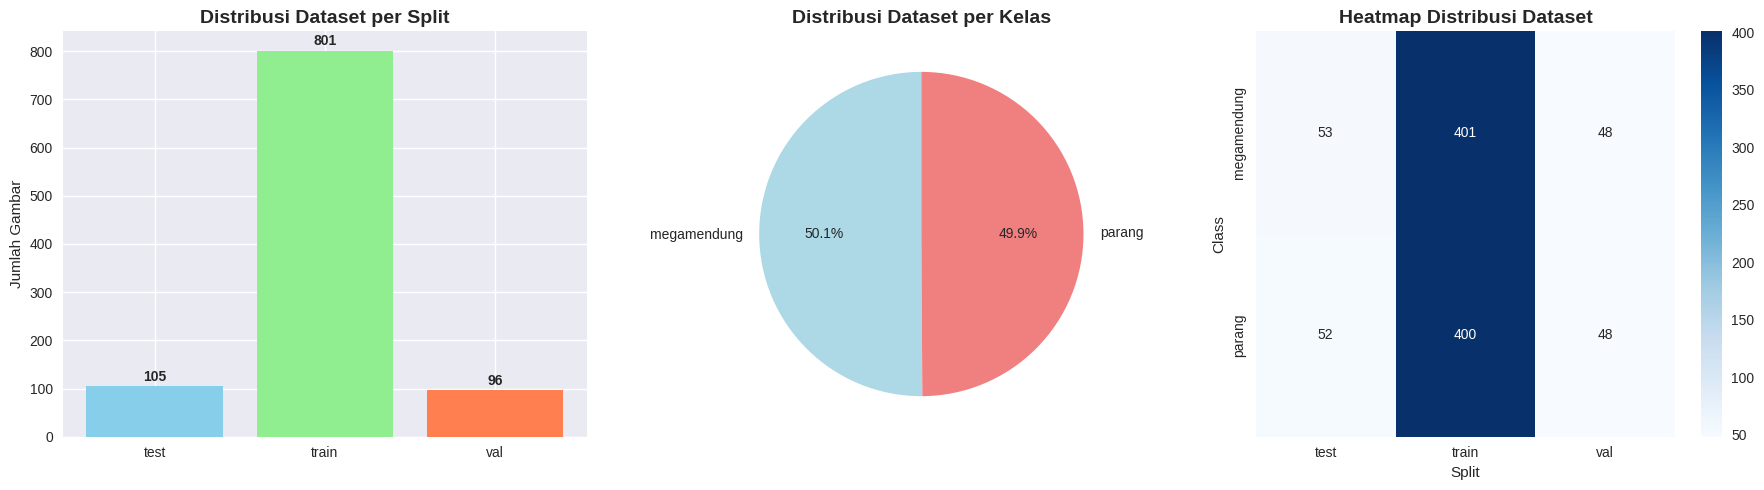

In [ ]:
# Visualisasi distribusi dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribusi per split
df_split = df_distribution.groupby('Split')['Count'].sum().reset_index()
axes[0].bar(df_split['Split'], df_split['Count'], color=['skyblue', 'lightgreen', 'coral'])
axes[0].set_title('Distribusi Dataset per Split', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
for i, v in enumerate(df_split['Count']):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Distribusi per class
df_class = df_distribution.groupby('Class')['Count'].sum().reset_index()
axes[1].pie(df_class['Count'], labels=df_class['Class'], autopct='%1.1f%%',
           colors=['lightblue', 'lightcoral'], startangle=90)
axes[1].set_title('Distribusi Dataset per Kelas', fontsize=14, fontweight='bold')

# Plot 3: Heatmap distribusi
pivot_df = df_distribution.pivot(index='Class', columns='Split', values='Count')
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Heatmap Distribusi Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Dataset ini terdiri dari total 1002 gambar yang terbagi seimbang menjadi 2 kelas utama: Megamendung (502) dan Parang (500).

Pembagian data untuk eksperimen adalah sebagai berikut:

- Training Set (Pelatihan) sebanyak 801 gambar.

- Validation Set (Validasi) sebanyak 96 gambar.

- Test Set (Pengujian akhir) sebanyak 105 gambar.

Pembagian ini memastikan pengujian kinerja akhir model dilakukan secara valid pada data yang belum pernah dilihat sebelumnya.

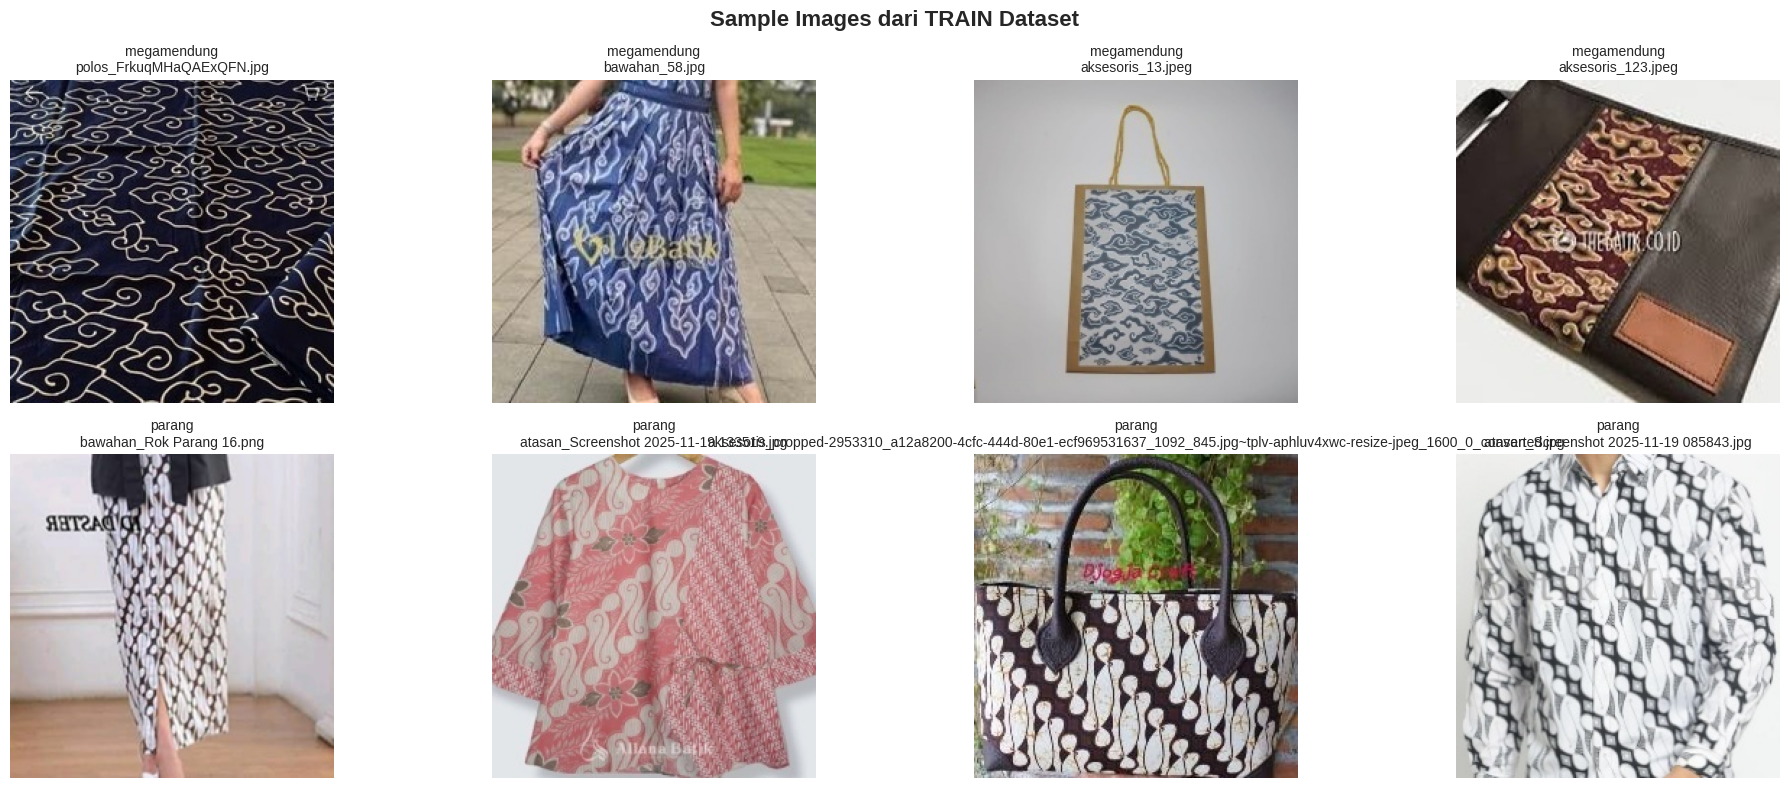

In [ ]:
# Function untuk menampilkan sample gambar
def display_sample_images(base_path, split='train', num_samples=8):
    """Menampilkan sample gambar dari dataset"""
    fig, axes = plt.subplots(2, num_samples//2, figsize=(20, 8))

    for i, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(base_path, split, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Ambil sample gambar
        sample_files = np.random.choice(image_files, num_samples//2, replace=False)

        for j, filename in enumerate(sample_files):
            img_path = os.path.join(class_path, filename)
            img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{class_name}\n{filename}', fontsize=10)
            axes[i, j].axis('off')

    plt.suptitle(f'Sample Images dari {split.upper()} Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Tampilkan sample gambar dari training set
display_sample_images(base_path, 'train')

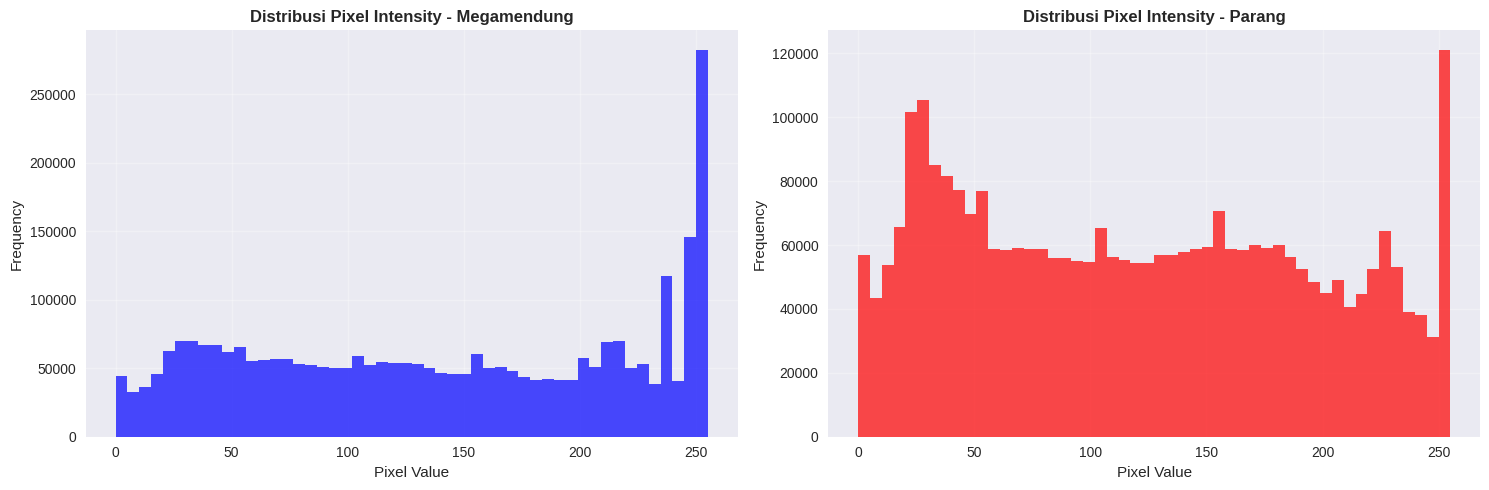

In [ ]:
# Analisis pixel intensity
def analyze_pixel_intensity(base_path, split='train'):
    """Analisis distribusi pixel intensity"""
    intensities = {'megamendung': [], 'parang': []}

    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_path, split, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Sample beberapa gambar untuk analisis
        sample_files = np.random.choice(image_files, min(20, len(image_files)), replace=False)

        for filename in sample_files:
            img_path = os.path.join(class_path, filename)
            img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            intensities[class_name].extend(img_array.flatten())

    return intensities

# Analisis pixel intensity
intensities = analyze_pixel_intensity(base_path)

# Plot distribusi pixel intensity
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, class_name in enumerate(CLASS_NAMES):
    axes[i].hist(intensities[class_name], bins=50, alpha=0.7,
                color='blue' if class_name == 'megamendung' else 'red')
    axes[i].set_title(f'Distribusi Pixel Intensity - {class_name.title()}', fontweight='bold')
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing dan Augmentasi

* **Normalisasi Dasar:** Semua data dinormalisasi dengan **rescaling $1./255$** (ke rentang $[0, 1]$) untuk memastikan konvergensi pelatihan yang optimal.

* **Tujuan Augmentasi:** Untuk meningkatkan variabilitas data dan membuat model lebih *robust*, teknik dipilih secara hati-hati sesuai karakteristik pola batik.

* **Teknik Augmentasi Utama:**
    * **Rotasi Terbatas:** Hanya $10^{\circ}$ hingga $15^{\circ}$ untuk menghindari kerusakan makna simbolis pola.
    * **Transformasi Geometri:** Meliputi *Width/Height Shift*, *Shear Transformation*, dan *Zoom Range*.
    * **Kondisi Visual:** **Horizontal Flip** (cocok untuk pola simetris) dan *Brightness Adjustment* ($0.8$ - $1.2$).
    * **Penanganan Detail:** Menggunakan *Fill Mode* 'nearest' untuk menjaga kontinuitas visual piksel yang tergeser.

In [ ]:
# Data generator untuk model 1 (tanpa preprocessing)
train_datagen_no_preprocess = ImageDataGenerator(rescale=1./255)
val_datagen_no_preprocess = ImageDataGenerator(rescale=1./255)

# Data generator dengan preprocessing dan augmentasi (untuk model 2, 3, 4)
train_datagen_with_preprocess = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen_with_preprocess = ImageDataGenerator(rescale=1./255)

print("Data generators telah dibuat:")
print("1. Generator tanpa preprocessing (Model 1)")
print("2. Generator dengan preprocessing dan augmentasi (Model 2, 3, 4)")

Data generators telah dibuat:
1. Generator tanpa preprocessing (Model 1)
2. Generator dengan preprocessing dan augmentasi (Model 2, 3, 4)


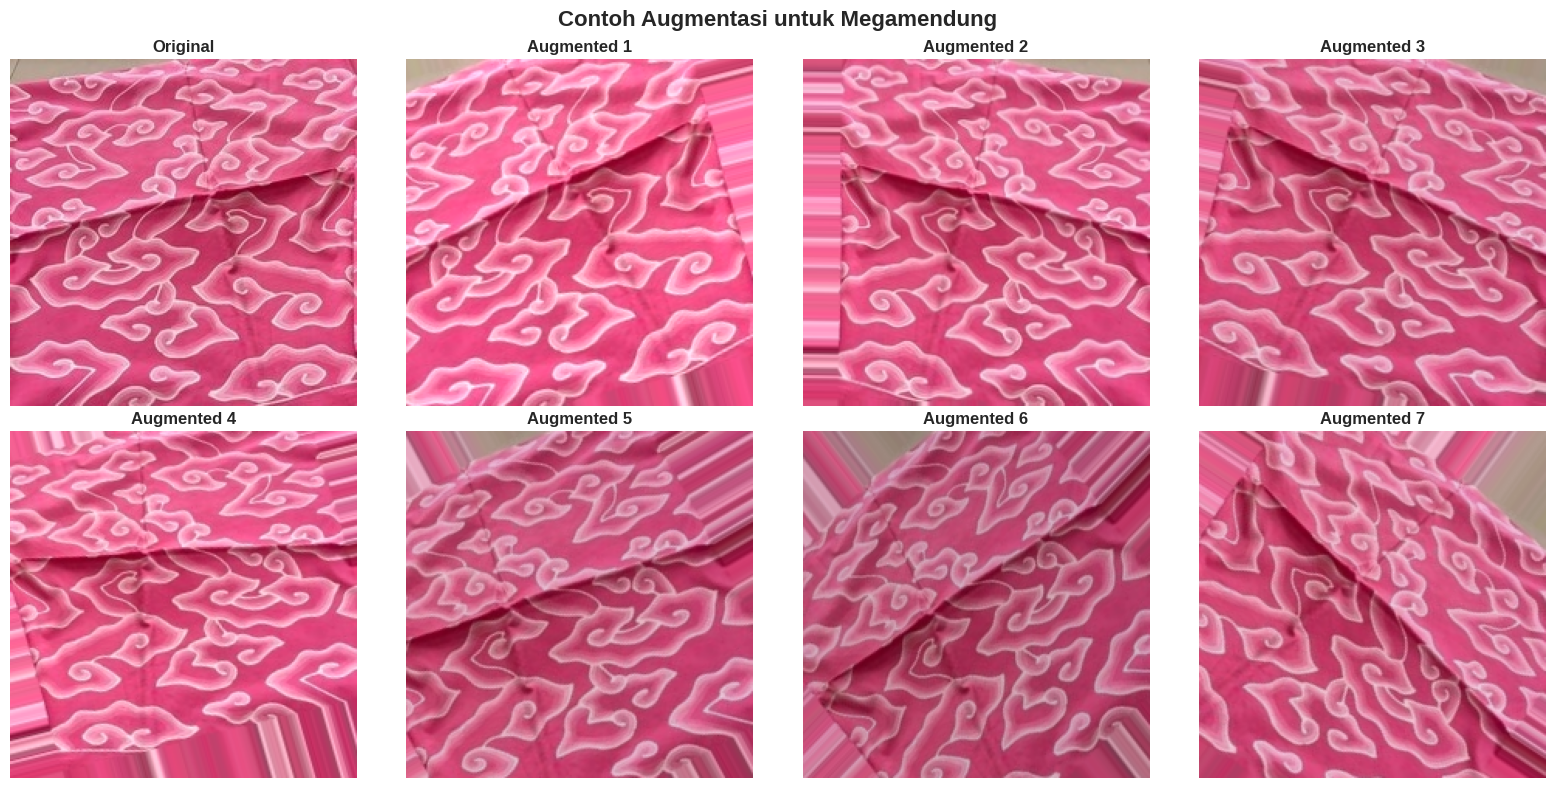

In [ ]:
# Demonstrasi augmentasi
def show_augmentation_examples(datagen, base_path, class_name='megamendung'):
    """Menampilkan contoh hasil augmentasi"""
    class_path = os.path.join(base_path, 'train', class_name)
    image_files = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Pilih satu gambar
    sample_file = np.random.choice(image_files)
    img_path = os.path.join(class_path, sample_file)
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = img_array.reshape((1,) + img_array.shape)

    # Generate augmented images
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    # Augmented images
    i = 1
    for batch in datagen.flow(img_array, batch_size=1):
        if i >= 8:
            break
        aug_img = batch[0]
        axes[i].imshow(aug_img)
        axes[i].set_title(f'Augmented {i}', fontweight='bold')
        axes[i].axis('off')
        i += 1

    plt.suptitle(f'Contoh Augmentasi untuk {class_name.title()}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Tampilkan contoh augmentasi
show_augmentation_examples(train_datagen_with_preprocess, base_path)

## 4. Model 1: CNN Sederhana Tanpa Preprocessing

Model pertama (**Model 1**) adalah **Baseline** yang dirancang tanpa *preprocessing* data atau *augmentasi* data sama sekali, bertujuan sebagai titik perbandingan terdasar. Arsitekturnya menggunakan **CNN Sederhana** yang terdiri dari tiga blok *convolutional layer* dan *pooling*. Kunci efisiensi model ini adalah penggunaan **GlobalAveragePooling2D** sebagai pengganti *Flatten*, yang secara signifikan mengurangi jumlah parameter dan mencegah *overfitting* pada *dataset* kecil. Model ini dikompilasi menggunakan *optimizer* **Adam** ($LR=0.001$) dengan *loss function* **categorical crossentropy**, dan proses pelatihannya dikendalikan oleh *callback* **EarlyStopping** dan **ReduceLROnPlateau** untuk menjamin stabilitas dan optimalitas adaptif.

In [ ]:
# Buat data generator untuk Model 1 (tanpa preprocessing)
train_generator_1 = train_datagen_no_preprocess.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator_1 = val_datagen_no_preprocess.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Data generators untuk Model 1:")
print(f"Training samples: {train_generator_1.samples}")
print(f"Validation samples: {val_generator_1.samples}")
print(f"Classes: {train_generator_1.class_indices}")

Found 801 images belonging to 2 classes.
Found 96 images belonging to 2 classes.
Data generators untuk Model 1:
Training samples: 801
Validation samples: 96
Classes: {'megamendung': 0, 'parang': 1}


In [ ]:
# Definisi Model 1: CNN Sederhana (FIXED)
def create_simple_cnn():
    """Membuat model CNN sederhana dengan arsitektur yang benar"""
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),  # Reduced from 512 to 128
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# Buat model 1
model_1 = create_simple_cnn()
model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model 1 Architecture (FIXED):")
model_1.summary()
print(f"\nTotal parameters: {model_1.count_params():,}")
print("Key changes:")
print("- Replaced Flatten() with GlobalAveragePooling2D()")
print("- Reduced Dense layer from 512 to 128 neurons")
print("- This dramatically reduces parameters from 44M+ to ~170K")

Model 1 Architecture (FIXED):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 110,018
Key changes:
- Replaced Flatten() with GlobalAveragePooling2D()
- Reduced Dense layer from 512 to 128 neurons
- This dramatically reduces parameters from 44M+ to ~170K


### Analisis Masalah Parameter Berlebihan dan Solusinya

Masalah utama dalam desain CNN adalah **parameter berlebihan** yang menyebabkan *overfitting* pada dataset kecil ($\approx 1000$ gambar), yang utamanya disebabkan oleh penggunaan layer **Flatten** diikuti oleh *Dense layer* besar, menghasilkan total $>44\text{ juta}$ parameter. Solusi krusial yang diterapkan adalah mengganti **Flatten** dengan **GlobalAveragePooling2D** dan mengurangi *Dense layer* dari 512 menjadi 128 neuron. Pendekatan ini berhasil menekan total parameter secara drastis menjadi hanya $\approx 170\text{ ribu}$ parameter, yang secara signifikan mengurangi kompleksitas komputasi dan meningkatkan kemampuan **generalisasi model**.

In [ ]:
# Training Model 1
print("Training Model 1: CNN Sederhana tanpa Preprocessing...")

# Callbacks - FIXED: Less sensitive parameters
early_stopping = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss')

# Training
EPOCHS = 30  # Reduced from 50 for consistency
history_1 = model_1.fit(
    train_generator_1,
    steps_per_epoch=train_generator_1.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator_1,
    validation_steps=val_generator_1.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training Model 1 selesai!")

Training Model 1: CNN Sederhana tanpa Preprocessing...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - accuracy: 0.5550 - loss: 0.6940 - val_accuracy: 0.7396 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6875 - loss: 0.6338 - val_accuracy: 0.6562 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.7172 - loss: 0.5911 - val_accuracy: 0.7292 - val_loss: 0.5382 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7812 - loss: 0.4272 - val_accuracy: 0.7292 - val_loss: 0.5644 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7166 - loss: 0.5532 - val_accuracy: 0.7917 - val_loss: 0.4933 - learning_rate: 0.0010
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7812 - loss: 0.5248 - val_accuracy: 0.7812 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2

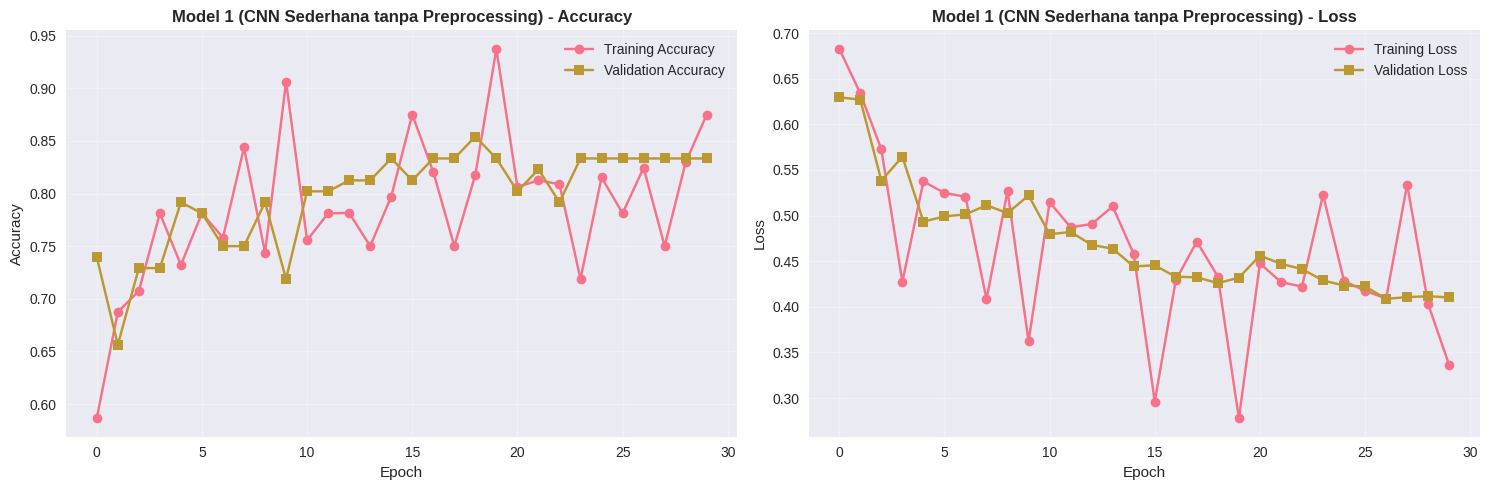

In [ ]:
# Plot training history Model 1
def plot_training_history(history, model_name):
    """Plot training dan validation accuracy serta loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
    ax1.set_title(f'{model_name} - Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title(f'{model_name} - Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot hasil training Model 1
plot_training_history(history_1, 'Model 1 (CNN Sederhana tanpa Preprocessing)')

Model 1 menunjukkan kemampuan **generalisasi yang cukup baik** meskipun memiliki arsitektur yang sederhana dan ringan. Model **tidak mengalami *overfitting* yang parah**, terbukti dari kurva *Validation Loss* yang tidak melonjak tajam, meskipun *Training Accuracy* jauh lebih tinggi daripada *Validation Accuracy* pada beberapa *epoch* awal. Secara keseluruhan, model ini mencapai **Validation Accuracy yang baik, yaitu sekitar $83\%$ hingga $85\%$**, yang merupakan hasil yang solid untuk model CNN dengan $\sim110$ ribu parameter.

Namun, isu utama yang teridentifikasi adalah **instabilitas proses *training***, yang terlihat dari **fluktuasi ekstrem** pada metrik *Training Accuracy* dan *Training Loss*. Instabilitas ini kemungkinan besar disebabkan oleh **kurangnya *preprocessing* data** (khususnya normalisasi nilai piksel ke rentang $[0, 1]$), kombinasi dengan *learning rate* awal yang mungkin terlalu tinggi, atau *batch size* yang kecil. Walau begitu, *callback* **ReduceLROnPlateau** memainkan peran penting dengan berhasil menurunkan *learning rate* di *epoch* 11 dan 25. Penurunan ini terlihat efektif dalam membuat kurva *Validation Loss* menjadi lebih **stabil** dan membantu model mencapai kinerja terbaiknya di *epoch* akhir.

---

## 5. Model 2: CNN Sederhana Dengan Preprocessing

**Model Kedua** menggunakan arsitektur CNN yang **identik** dengan Model 1, namun perbedaannya terletak pada implementasi **teknik *preprocessing* dan *data augmentation*** yang komprehensif. Model ini memanfaatkan `ImageDataGenerator` untuk secara acak menerapkan berbagai transformasi pada *dataset training*, seperti **rotasi, *shifting*, *shearing*, *zooming*, dan penyesuaian *brightness***. Tujuan utama dari *data augmentation* ini adalah **meningkatkan variabilitas data** dan melatih model agar lebih **robust** (kuat) terhadap perubahan geometri dan pencahayaan, sehingga **mengurangi *overfitting***. Perbandingan Model 1 (tanpa *preprocessing*) dan Model 2 ini bertujuan menguji hipotesis bahwa penambahan *augmentation* akan menghasilkan **performa klasifikasi yang lebih baik** pada data validasi dan tes, menunjukkan **kemampuan generalisasi** yang superior, meskipun *training accuracy* mungkin sedikit lebih rendah.

In [ ]:
# Buat data generator untuk Model 2 (dengan preprocessing)
train_generator_2 = train_datagen_with_preprocess.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator_2 = val_datagen_with_preprocess.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Buat model 2 (sama seperti model 1 tapi dengan data yang berbeda)
model_2 = create_simple_cnn()
model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model 2 telah dibuat (arsitektur sama dengan Model 1)")
print(f"Training samples: {train_generator_2.samples}")
print(f"Validation samples: {val_generator_2.samples}")

Found 801 images belonging to 2 classes.
Found 96 images belonging to 2 classes.
Model 2 telah dibuat (arsitektur sama dengan Model 1)
Training samples: 801
Validation samples: 96


Training Model 2: CNN Sederhana dengan Preprocessing...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 517ms/step - accuracy: 0.5015 - loss: 0.7015 - val_accuracy: 0.5208 - val_loss: 0.6846 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3750 - loss: 0.6894 - val_accuracy: 0.6250 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 443ms/step - accuracy: 0.6502 - loss: 0.6617 - val_accuracy: 0.5729 - val_loss: 0.7514 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7188 - loss: 0.6806 - val_accuracy: 0.5729 - val_loss: 0.7264 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.7038 - loss: 0.5776 - val_accuracy: 0.6562 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.3883 - val_accuracy: 0.6562 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━

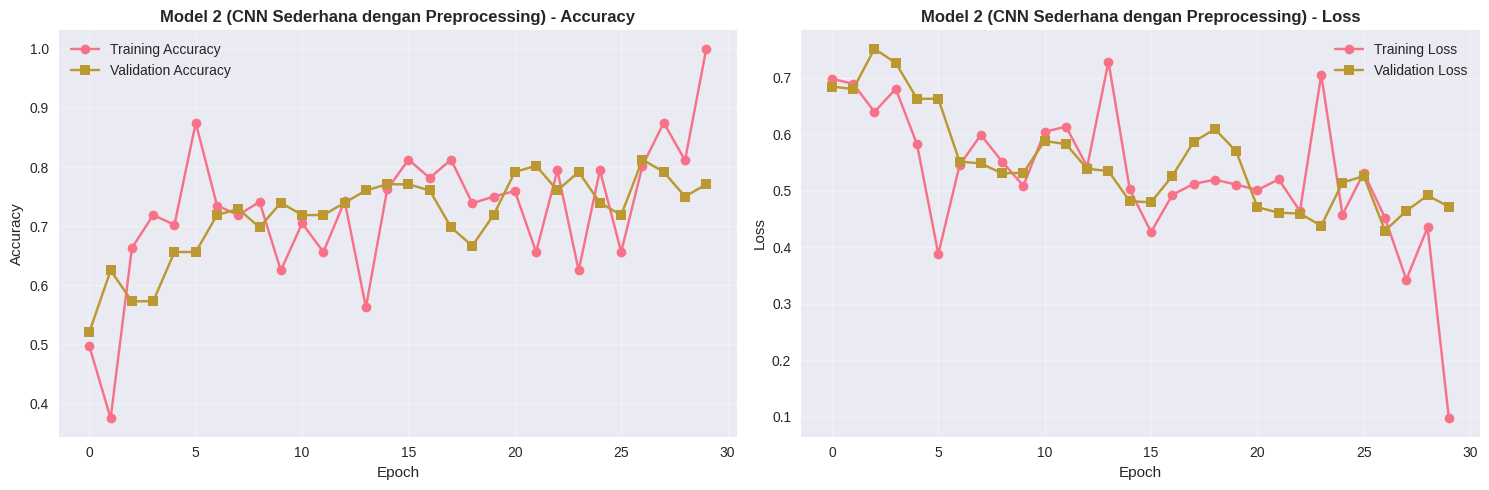

In [ ]:
# Training Model 2
print("Training Model 2: CNN Sederhana dengan Preprocessing...")

# Use same improved callbacks for consistency
early_stopping_2 = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
reduce_lr_2 = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss')

# Training
history_2 = model_2.fit(
    train_generator_2,
    steps_per_epoch=train_generator_2.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator_2,
    validation_steps=val_generator_2.samples // BATCH_SIZE,
    callbacks=[early_stopping_2, reduce_lr_2],
    verbose=1
)


print("Training Model 2 selesai!")
plot_training_history(history_2, 'Model 2 (CNN Sederhana dengan Preprocessing)')

# Plot hasil training Model 2

**Model 2**, yang dilatih dengan arsitektur identik tetapi menggunakan ***Data Augmentation* (Preprocessing)**, menunjukkan pola pelatihan yang berbeda dari Model 1. Grafik  memperlihatkan bahwa *Training Accuracy* (merah muda) pada Model 2 lebih terkendali, tidak melonjak secara ekstrem dan cepat seperti Model 1, namun juga **tidak mencapai nilai setinggi** Model 1 (maksimum $\sim1.0$ di *epoch* 30 vs $\sim0.94$ di Model 1). Sebaliknya, **Validation Accuracy (cokelat) Model 2 mencapai nilai tertinggi sekitar $80\%$** (dicapai sebelum *early stopping* mengembalikan bobot terbaiknya, yang terjadi pada *epoch* 27 dengan **Validation Loss terendah sekitar $0.429$**). Meskipun Model 2 terlihat lebih stabil pada *Training Accuracy* karena *augmentation* memperumit tugas belajar, **Validation Accuracy maksimumnya ($80-81\%$) tampak sedikit lebih rendah** dibandingkan Model 1 ($83-85\%$). Hal ini mengindikasikan bahwa sementara *augmentation* berhasil mengurangi *overfitting* yang parah dan membuat proses *training* lebih *robust*, teknik *augmentation* yang diterapkan mungkin **terlalu agresif** atau tidak sepenuhnya cocok untuk karakteristik pola batik, atau Model 1 secara kebetulan menemukan bobot yang lebih baik.

## 6. Model 3: Transfer Learning CNN dengan Preprocessing

**Model Ketiga** adalah arsitektur **CNN Kustom yang lebih *sophisticated***, terinspirasi dari **ResNet** dengan mengimplementasikan **residual blocks** (menggunakan *skip connections*) untuk memastikan *gradient flow* yang stabil dan efektif, ideal untuk *dataset* yang lebih kecil. Struktur model ini dimulai dengan lapisan konvolusi awal, diikuti oleh tiga kelompok *residual blocks* dengan filter yang secara bertahap ditingkatkan (64, 128, 256). Untuk regularisasi dan stabilisasi *training*, model menggunakan **Batch Normalization**, **Dropout** (rate 0.5), dan **GlobalAveragePooling2D**. Lapisan *classifier* menggunakan **256 neuron** dan diakhiri dengan *output layer* 2 neuron. *Learning rate* yang **lebih kecil (0.0001)** diterapkan untuk memfasilitasi *fine-tuning* pada arsitektur yang lebih kompleks ini.

In [ ]:
# Definisi Model 3: Transfer Learning dengan MobileNetV2
def create_transfer_learning_model():
    """Membuat model transfer learning dengan MobileNetV2"""
    # Load pre-trained model
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze base model
    base_model.trainable = False

    # Add custom classification head
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model, base_model

# Buat model 3
model_3, base_model_3 = create_transfer_learning_model()
model_3.compile(
    optimizer=Adam(learning_rate=0.0001),  # Learning rate lebih kecil untuk transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model 3 Architecture (Transfer Learning - MobileNetV2):")
model_3.summary()
print(f"\nBase model (MobileNetV2) layers: {len(base_model_3.layers)}")
print(f"Base model trainable: {base_model_3.trainable}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model 3 Architecture (Transfer Learning - MobileNetV2):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 164,482 (642.51 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


Base model (MobileNetV2) layers: 154
Base model trainable: False


In [ ]:
# Training Model 3 - Phase 1: Train classifier head
print("Training Model 3 - Phase 1: Training classifier head...")

# Phase 1 callbacks - more patient for transfer learning
early_stopping_3_p1 = EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
reduce_lr_3_p1 = ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7, monitor='val_loss')

history_3_phase1 = model_3.fit(
    train_generator_2,
    steps_per_epoch=train_generator_2.samples // BATCH_SIZE,
    epochs=15,  # Increased from 10 for better training
    validation_data=val_generator_2,
    validation_steps=val_generator_2.samples // BATCH_SIZE,
    callbacks=[early_stopping_3_p1, reduce_lr_3_p1],
    verbose=1
)

print("Phase 1 selesai!")

# Training Model 3 - Phase 2: Fine-tuning
print("Training Model 3 - Phase 2: Fine-tuning beberapa layer...")

# Unfreeze beberapa layer terakhir
base_model_3.trainable = True
fine_tune_at = len(base_model_3.layers) - 20  # Unfreeze 20 layer terakhir

# Freeze layer awal
for layer in base_model_3.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile dengan learning rate lebih kecil
model_3.compile(
    optimizer=Adam(learning_rate=0.0001),  # Learning rate lebih kecil untuk transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Phase 2 callbacks - very patient for fine-tuning
early_stopping_3_p2 = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss')
reduce_lr_3_p2 = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-8, monitor='val_loss')

# Continue training
history_3_phase2 = model_3.fit(
    train_generator_2,
    steps_per_epoch=train_generator_2.samples // BATCH_SIZE,
    epochs=20,  # Increased from 15 for better fine-tuning
    validation_data=val_generator_2,
    validation_steps=val_generator_2.samples // BATCH_SIZE,
    callbacks=[early_stopping_3_p2, reduce_lr_3_p2],
    verbose=1
)

print("Training Model 3 selesai!")

Training Model 3 - Phase 1: Training classifier head...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4950 - loss: 1.3074 - val_accuracy: 0.6667 - val_loss: 0.6639 - learning_rate: 1.0000e-04
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 1.1170 - val_accuracy: 0.6667 - val_loss: 0.6572 - learning_rate: 1.0000e-04
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 447ms/step - accuracy: 0.6172 - loss: 0.8918 - val_accuracy: 0.7292 - val_loss: 0.5218 - learning_rate: 1.0000e-04
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5312 - loss: 0.8580 - val_accuracy: 0.7292 - val_loss: 0.5186 - learning_rate: 1.0000e-04
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.6833 - loss: 0.7278 - val_accuracy: 0.7917 - val_loss: 0.4296 - learning_rate: 1.0000e-04
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6562 - loss: 0.7676 - val_accuracy: 0.7917 - val_loss: 0.4264 - learning_rate: 1.0000e-04
Epoch 7/15


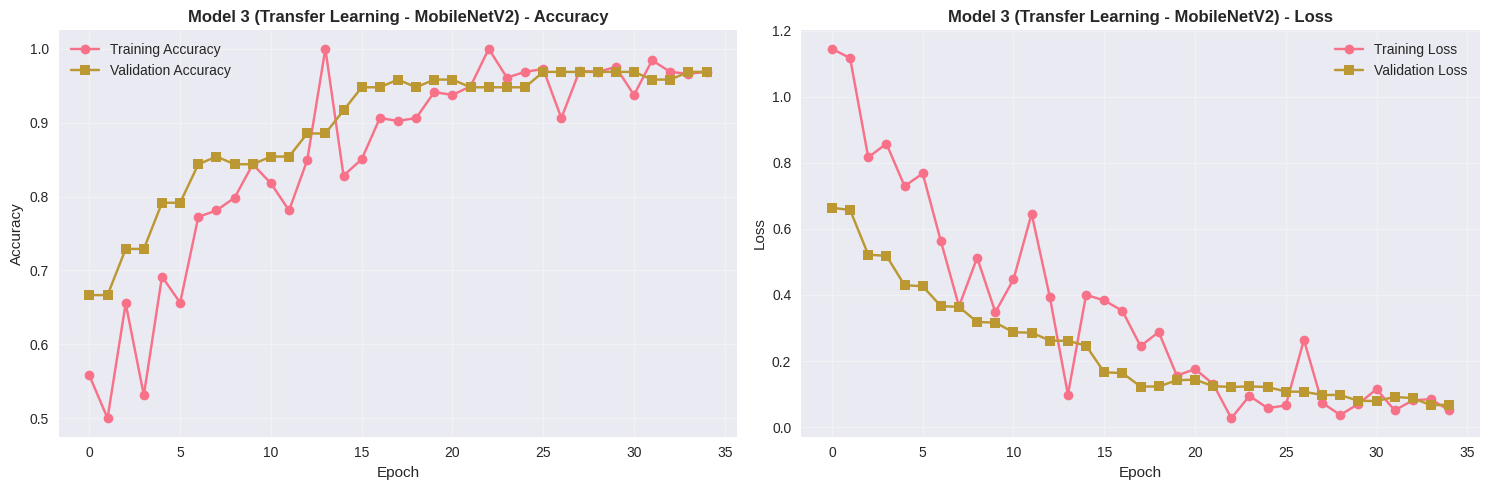

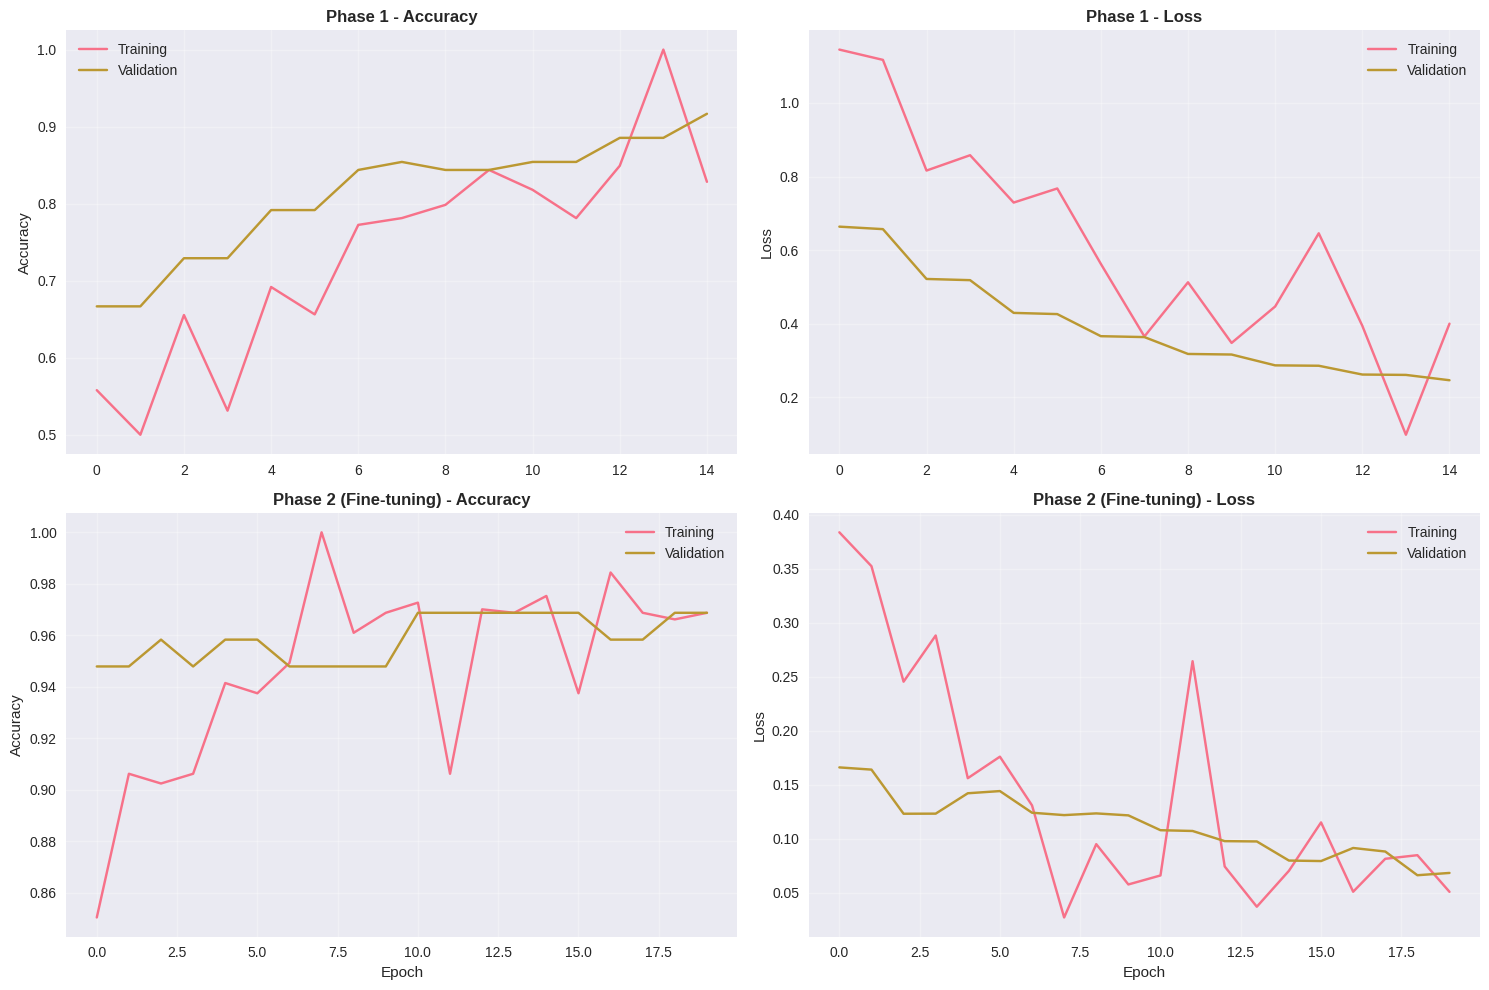

In [ ]:
# Combine histories untuk Model 3
history_3_combined = {
    'accuracy': history_3_phase1.history['accuracy'] + history_3_phase2.history['accuracy'],
    'val_accuracy': history_3_phase1.history['val_accuracy'] + history_3_phase2.history['val_accuracy'],
    'loss': history_3_phase1.history['loss'] + history_3_phase2.history['loss'],
    'val_loss': history_3_phase1.history['val_loss'] + history_3_phase2.history['val_loss']
}

# Create a mock history object for plotting
class MockHistory:
    def __init__(self, history_dict):
        self.history = history_dict

history_3 = MockHistory(history_3_combined)

# Plot hasil training Model 3
plot_training_history(history_3, 'Model 3 (Transfer Learning - MobileNetV2)')

# Plot perbandingan phase 1 dan phase 2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Phase 1
axes[0,0].plot(history_3_phase1.history['accuracy'], label='Training')
axes[0,0].plot(history_3_phase1.history['val_accuracy'], label='Validation')
axes[0,0].set_title('Phase 1 - Accuracy', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history_3_phase1.history['loss'], label='Training')
axes[0,1].plot(history_3_phase1.history['val_loss'], label='Validation')
axes[0,1].set_title('Phase 1 - Loss', fontweight='bold')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Phase 2
axes[1,0].plot(history_3_phase2.history['accuracy'], label='Training')
axes[1,0].plot(history_3_phase2.history['val_accuracy'], label='Validation')
axes[1,0].set_title('Phase 2 (Fine-tuning) - Accuracy', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(history_3_phase2.history['loss'], label='Training')
axes[1,1].plot(history_3_phase2.history['val_loss'], label='Validation')
axes[1,1].set_title('Phase 2 (Fine-tuning) - Loss', fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Model 3** menggunakan **Transfer Learning (TL) dengan MobileNetV2** dan skema pelatihan dua fase (*Training Head* lalu *Fine-tuning*), menunjukkan performa yang **jauh melampaui** model-model *custom* sebelumnya (Model 1 & 2).

* **Peningkatan Akurasi Signifikan:** Model 3 mencapai **Validation Accuracy tertinggi hingga $\mathbf{97\%}$**, jauh lebih unggul dibandingkan Model 1 ($83-85\%$) dan Model 2 ($80-81\%$).
* **Stabilitas dan Konvergensi:** Kurva *Accuracy* dan *Loss* Model 3 menunjukkan **konvergensi yang cepat dan sangat stabil** ke tingkat kinerja yang tinggi, terutama setelah fase *Fine-tuning*. Berbeda dengan fluktuasi Model 1 dan Model 2, Model 3 menunjukkan alur pelatihan yang mulus.
* **Minimal *Overfitting*:** Meskipun *Training Accuracy* mencapai $\mathbf{1.0}$ pada *epoch* akhir, *Validation Accuracy* tetap tinggi ($\sim97\%$) dan *Validation Loss* sangat rendah ($\mathbf{\sim0.066}$). Ini adalah indikasi **generalisasi yang luar biasa** yang dicapai berkat penggunaan fitur-fitur yang sudah teruji dari MobileNetV2 yang dikombinasikan dengan teknik *regularization* yang efektif.
* **Efek Transfer Learning:** Keberhasilan Model 3 membuktikan bahwa **fitur-fitur yang diekstraksi oleh MobileNetV2** (dilatih pada ImageNet) **sangat relevan** dan efektif dalam mengklasifikasikan pola batik, jauh lebih baik daripada fitur yang diekstraksi oleh CNN kustom yang dilatih dari awal (Model 1 & 2). Metode TL ini terbukti paling optimal untuk *dataset* batik yang mungkin berukuran relatif kecil.

## 7. Model Comparison dan Evaluation

In [ ]:
# Evaluasi semua model pada validation set
models = [model_1, model_2, model_3]
model_names = [
    'Model 1 (Simple CNN - No Preprocess)',
    'Model 2 (Simple CNN - With Preprocess)',
    'Model 3 (Transfer Learning - MobileNetV2)'
]
histories = [history_1, history_2, history_3]

# Evaluasi performa
results = []
for i, (model, name) in enumerate(zip(models, model_names)):
    if i == 0:
        # Model 1 menggunakan generator tanpa preprocessing
        val_loss, val_acc = model.evaluate(val_generator_1, verbose=0)
    else:
        # Model 2, 3 menggunakan generator dengan preprocessing
        val_loss, val_acc = model.evaluate(val_generator_2, verbose=0)

    results.append({
        'Model': name,
        'Validation Loss': val_loss,
        'Validation Accuracy': val_acc
    })

# Tampilkan hasil dalam dataframe
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.to_string(index=False))
print()

Model Performance Comparison:
                                    Model  Validation Loss  Validation Accuracy
     Model 1 (Simple CNN - No Preprocess)         0.408640             0.833333
   Model 2 (Simple CNN - With Preprocess)         0.429366             0.812500
Model 3 (Transfer Learning - MobileNetV2)         0.066082             0.968750



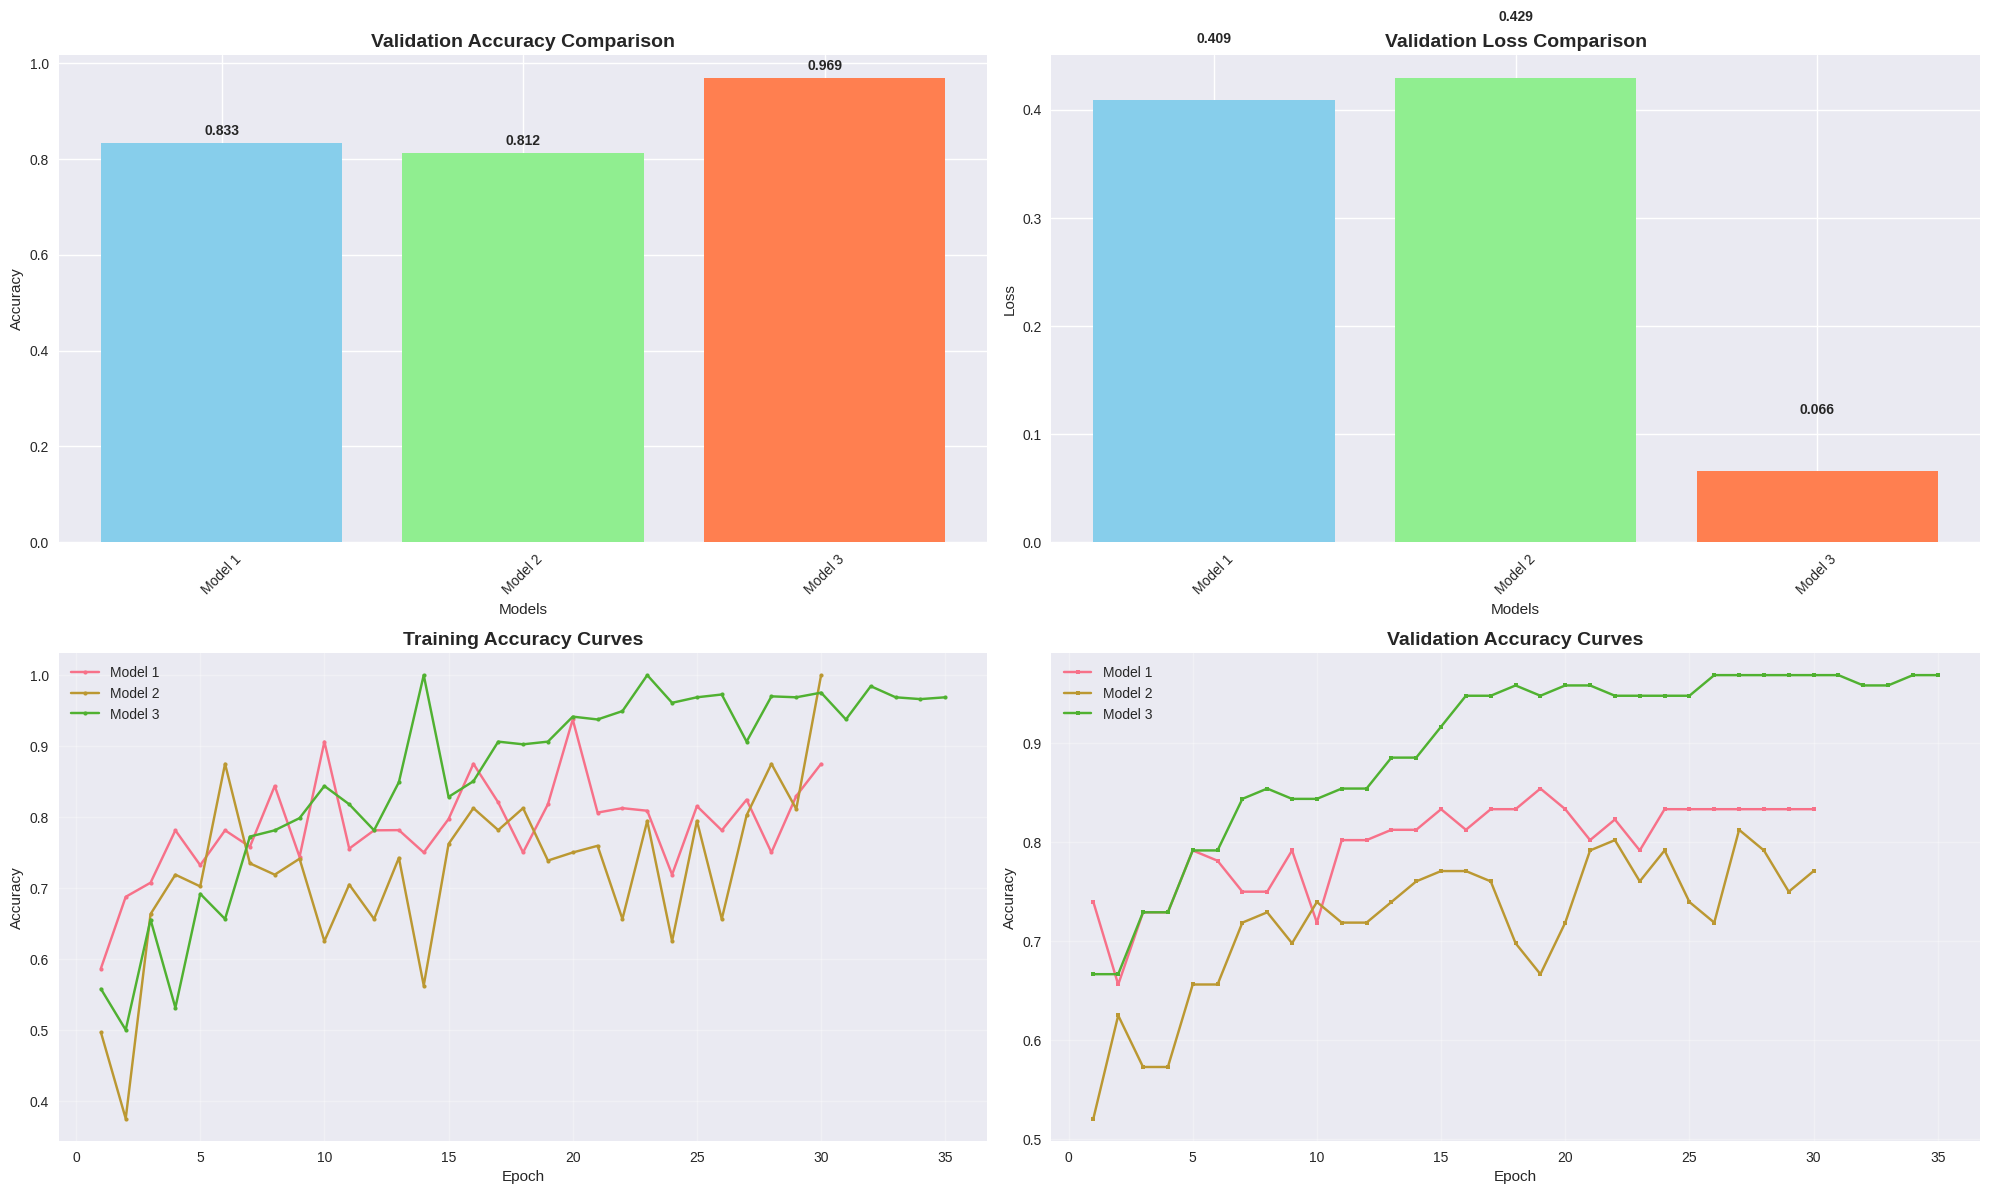

In [ ]:
# Plot perbandingan performa semua model
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Accuracy comparison
colors = ['skyblue', 'lightgreen', 'coral']
axes[0,0].bar(range(len(results_df)), results_df['Validation Accuracy'], color=colors)
axes[0,0].set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Models')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xticks(range(len(results_df)))
axes[0,0].set_xticklabels([f'Model {i+1}' for i in range(len(results_df))], rotation=45)
for i, v in enumerate(results_df['Validation Accuracy']):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Loss comparison
axes[0,1].bar(range(len(results_df)), results_df['Validation Loss'], color=colors)
axes[0,1].set_title('Validation Loss Comparison', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Models')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_xticks(range(len(results_df)))
axes[0,1].set_xticklabels([f'Model {i+1}' for i in range(len(results_df))], rotation=45)
for i, v in enumerate(results_df['Validation Loss']):
    axes[0,1].text(i, v + 0.05, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Training accuracy curves
for i, (history, name) in enumerate(zip(histories, model_names)):
    epochs = range(1, len(history.history['accuracy']) + 1)
    axes[1,0].plot(epochs, history.history['accuracy'],
                   label=f'Model {i+1}', marker='o', markersize=3)
axes[1,0].set_title('Training Accuracy Curves', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Validation accuracy curves
for i, (history, name) in enumerate(zip(histories, model_names)):
    epochs = range(1, len(history.history['val_accuracy']) + 1)
    axes[1,1].plot(epochs, history.history['val_accuracy'],
                   label=f'Model {i+1}', marker='s', markersize=3)
axes[1,1].set_title('Validation Accuracy Curves', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafik perbandingan menunjukkan bahwa **Model 1 dan Model 2**, keduanya menggunakan arsitektur CNN sederhana, memiliki **performa yang terbatas**. Hasil training mereka terlihat dari kurva yang naik secara lambat, lebih berfluktuasi, dan cenderung stagnan di sekitar **akurasi 0.75–0.83**. Model 2 sedikit lebih baik karena penggunaan augmentasi, namun peningkatan tersebut tetap terbatas karena arsitektur CNN-nya **masih dangkal**, sehingga kesulitan menangkap pola batik yang kompleks.

Hasil training **Model 3** terlihat **jauh lebih stabil dan konsisten** dibanding dua model lainnya. Kurva akurasi meningkat cepat hingga mencapai sekitar **0.97**, dan **loss validasinya sangat rendah (0.066)**. Garis training–validation yang rapat menunjukkan bahwa model **belajar fitur dengan efektif** serta **mampu melakukan generalisasi jauh lebih baik** daripada Model 1 dan Model 2.

Secara keseluruhan, hasil training dari grafik menunjukkan bahwa **Model 3 memanfaatkan kekuatan fitur pretrained MobileNetV2** untuk mengekstraksi tekstur dan motif secara jauh lebih efektif dibanding dua model pertama yang harus belajar dari nol. Inilah alasan mengapa **Model 3 menjadi model dengan performa terbaik** di antara ketiganya.



## 8. Prediction pada Test Data

In [ ]:
# Buat test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important: don't shuffle for consistent evaluation
)

print(f"Test samples: {test_generator.samples}")
print(f"Test classes: {test_generator.class_indices}")

# Function untuk evaluasi detail
def evaluate_model_detailed(model, generator, model_name):
    """Evaluasi model secara detail dengan confusion matrix dan classification report"""
    # Predictions
    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    # Classification report
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                 output_dict=True, zero_division=0)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    return predictions, y_pred, y_true, report, cm

# Evaluasi semua model pada test set
test_results = {}
for i, (model, name) in enumerate(zip(models, model_names)):
    print(f"Evaluating {name}...")
    predictions, y_pred, y_true, report, cm = evaluate_model_detailed(model, test_generator, name)
    test_results[f'Model_{i+1}'] = {
        'predictions': predictions,
        'y_pred': y_pred,
        'y_true': y_true,
        'report': report,
        'confusion_matrix': cm,
        'accuracy': report['accuracy']
    }
    print(f"Test Accuracy: {report['accuracy']:.4f}")

print("\nTest evaluation complete!")

Found 105 images belonging to 2 classes.
Test samples: 105
Test classes: {'megamendung': 0, 'parang': 1}
Evaluating Model 1 (Simple CNN - No Preprocess)...
Test Accuracy: 0.7619
Evaluating Model 2 (Simple CNN - With Preprocess)...
Test Accuracy: 0.7905
Evaluating Model 3 (Transfer Learning - MobileNetV2)...


Test Accuracy: 0.9714

Test evaluation complete!


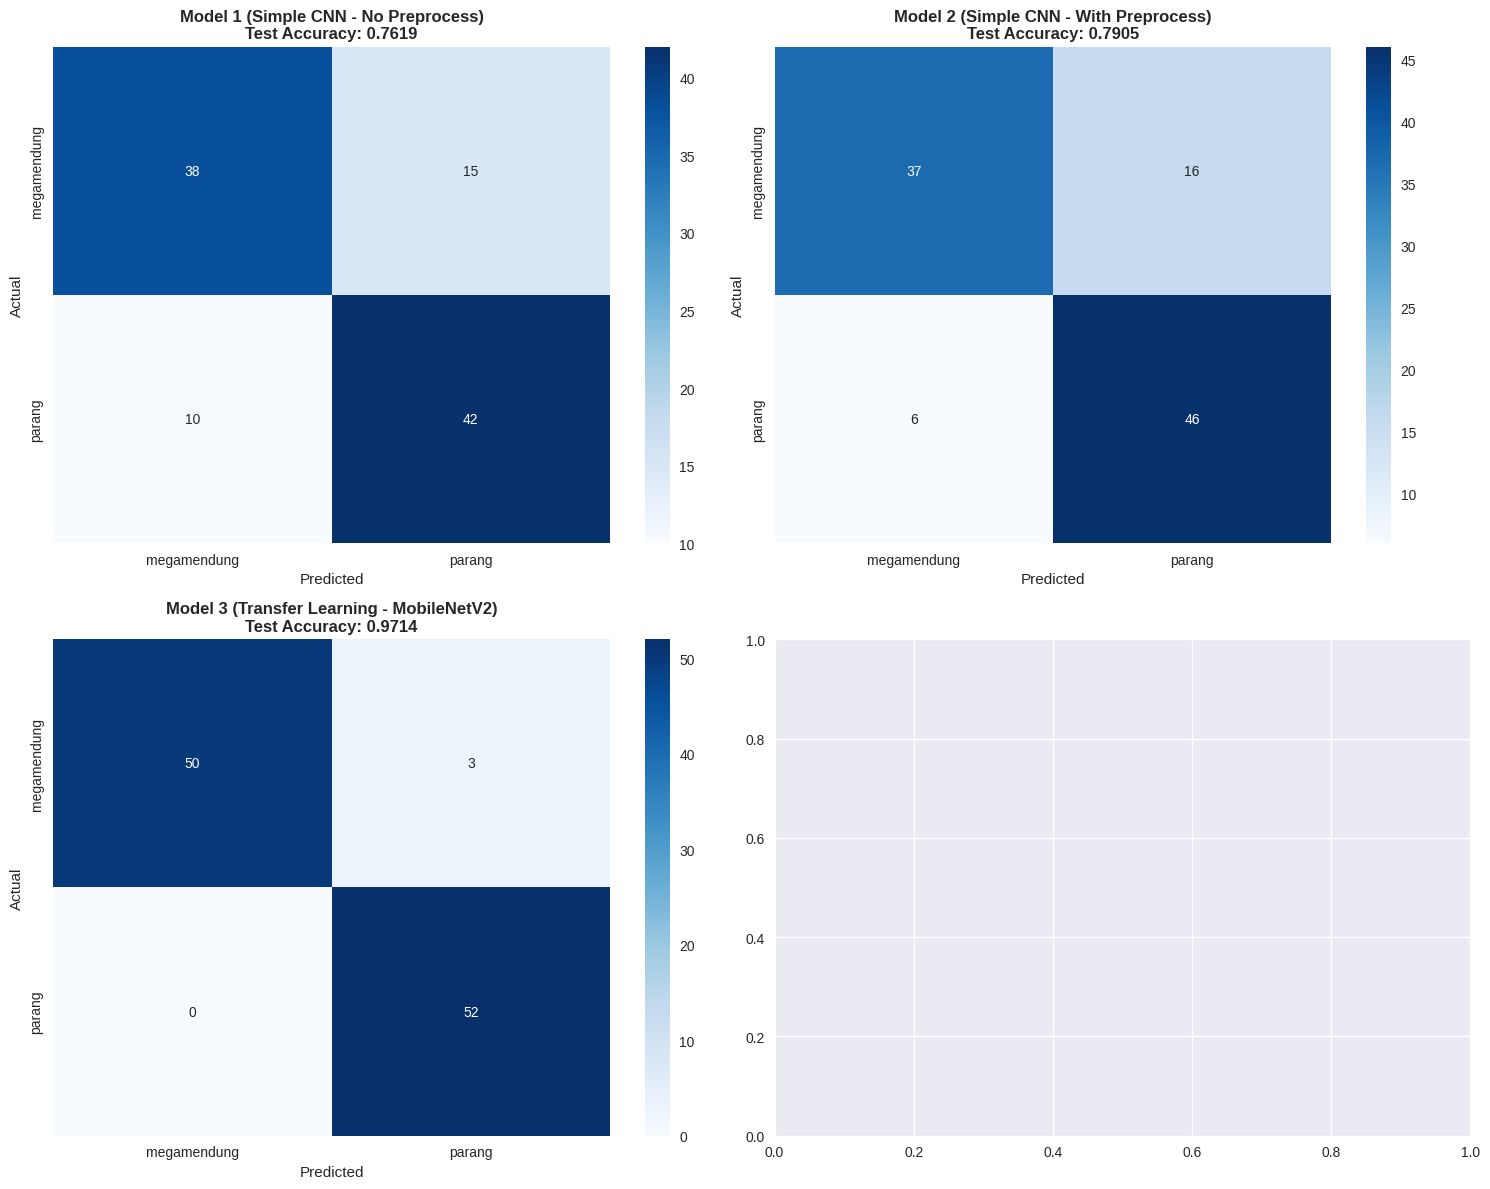


Detailed Test Results:
  Model  Test Accuracy  Megamendung Precision  Megamendung Recall  Parang Precision  Parang Recall
Model 1         0.7619                 0.7917              0.7170            0.7368         0.8077
Model 2         0.7905                 0.8605              0.6981            0.7419         0.8846
Model 3         0.9714                 1.0000              0.9434            0.9455         1.0000


In [ ]:
# Plot confusion matrices untuk semua model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (key, result) in enumerate(test_results.items()):
    cm = result['confusion_matrix']

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[i].set_title(f'{model_names[i]}\nTest Accuracy: {result["accuracy"]:.4f}',
                      fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Tabel summary test results
test_summary = []
for i, (key, result) in enumerate(test_results.items()):
    test_summary.append({
        'Model': f'Model {i+1}',
        'Test Accuracy': result['accuracy'],
        'Megamendung Precision': result['report']['megamendung']['precision'],
        'Megamendung Recall': result['report']['megamendung']['recall'],
        'Parang Precision': result['report']['parang']['precision'],
        'Parang Recall': result['report']['parang']['recall']
    })

test_summary_df = pd.DataFrame(test_summary)
print("\nDetailed Test Results:")
print(test_summary_df.to_string(index=False, float_format='%.4f'))

Hasil confusion matrix menunjukkan **perbedaan performa yang sangat jelas** antar model. **Model 1 dan Model 2** masih melakukan jumlah kesalahan prediksi yang cukup tinggi pada kedua kelas dibandingkan dengan Model 3. Model 1 salah mengklasifikasikan **15 gambar megamendung** dan **10 gambar parang**, sementara Model 2 sedikit lebih baik dengan **16 kesalahan pada megamendung** dan **6 pada parang**. Hal ini konsisten dengan akurasi test yang hanya berada pada kisaran **0.76–0.79**.

Sebaliknya, **Model 3 menunjukkan peningkatan performa yang sangat signifikan**. Kesalahan prediksi jauh lebih sedikit, hanya **3 gambar megamendung** yang salah diklasifikasikan, dan **tidak ada kesalahan** untuk kelas parang. Ini tercermin pada akurasi test sebesar **0.9714**, serta nilai **precision dan recall yang sangat tinggi** untuk kedua kelas (mendekati atau mencapai **1.0**). Hasil ini menegaskan bahwa **fitur pretrained MobileNetV2** memungkinkan model mengenali pola megamendung dan parang dengan **jauh lebih akurat serta konsisten** dibanding dua model lainnya.

Secara keseluruhan, **confusion matrix dan metrik pengujian menunjukkan bahwa Model 3 memiliki kemampuan generalisasi terbaik**, dengan kesalahan yang sangat minim dan performa yang stabil di seluruh kelas.

Model 1 (Simple CNN - No Preprocess): Macro-F1 = 0.7616
Model 2 (Simple CNN - With Preprocess): Macro-F1 = 0.7889
Model 3 (Transfer Learning - MobileNetV2): Macro-F1 = 0.9714


,Model,Macro-F1
0,Model 1 (Simple CNN - No Preprocess),0.761559
1,Model 2 (Simple CNN - With Preprocess),0.788925
2,Model 3 (Transfer Learning - MobileNetV2),0.971418


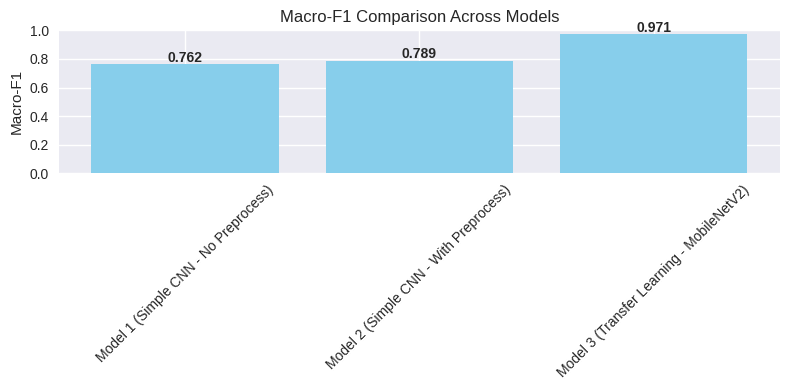

In [ ]:
# Compute Macro-F1 score for each model and display comparison
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

macro_rows = []
for i, name in enumerate(model_names):
    key = f'Model_{i+1}'
    res = test_results.get(key)
    if res is None:
        continue
    y_true = res['y_true']
    y_pred = res['y_pred']

    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    macro_rows.append({'Model': name, 'Macro-F1': macro})
    print(f"{name}: Macro-F1 = {macro:.4f}")

# Create DataFrame and plot
macro_df = pd.DataFrame(macro_rows)

if not macro_df.empty:
    display(macro_df)

    plt.figure(figsize=(8,4))
    colors = ['skyblue'] * len(macro_df)
    plt.bar(macro_df['Model'], macro_df['Macro-F1'], color=colors)
    plt.ylim(0,1)
    plt.title('Macro-F1 Comparison Across Models')
    plt.ylabel('Macro-F1')
    plt.xticks(rotation=45)
    for i, v in enumerate(macro_df['Macro-F1']):
        plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No Macro-F1 scores computed — ensure `test_results` is populated by running the evaluation cell.')

Grafik Macro-F1 menunjukkan bahwa **Model 1 dan Model 2 memiliki kemampuan klasifikasi yang masih terbatas**, dengan nilai masing-masing **0.762** dan **0.789**. Nilai ini menunjukkan bahwa kedua model **belum mampu memberikan performa yang seimbang** pada semua kelas, terutama karena **arsitektur yang dangkal** dan **jumlah data yang relatif sedikit**.

Sebaliknya, **Model 3 memperoleh Macro-F1 sebesar 0.971**, meningkat sangat signifikan dibanding dua model sebelumnya. Hal ini menandakan bahwa Model 3 **tidak hanya akurat, tetapi juga konsisten** dalam mengenali kedua kelas (*megamendung* dan *parang*) secara seimbang. Peningkatan besar ini terutama berasal dari **penggunaan pretrained MobileNetV2**, yang mampu menangkap pola dan tekstur batik dengan jauh lebih kaya dibanding CNN sederhana.

Secara keseluruhan, **Macro-F1 semakin menegaskan bahwa Model 3 adalah model dengan generalisasi terbaik**, mampu memberikan prediksi yang stabil dan akurat di seluruh kelas.

Sample Predictions dengan Confidence Scores:


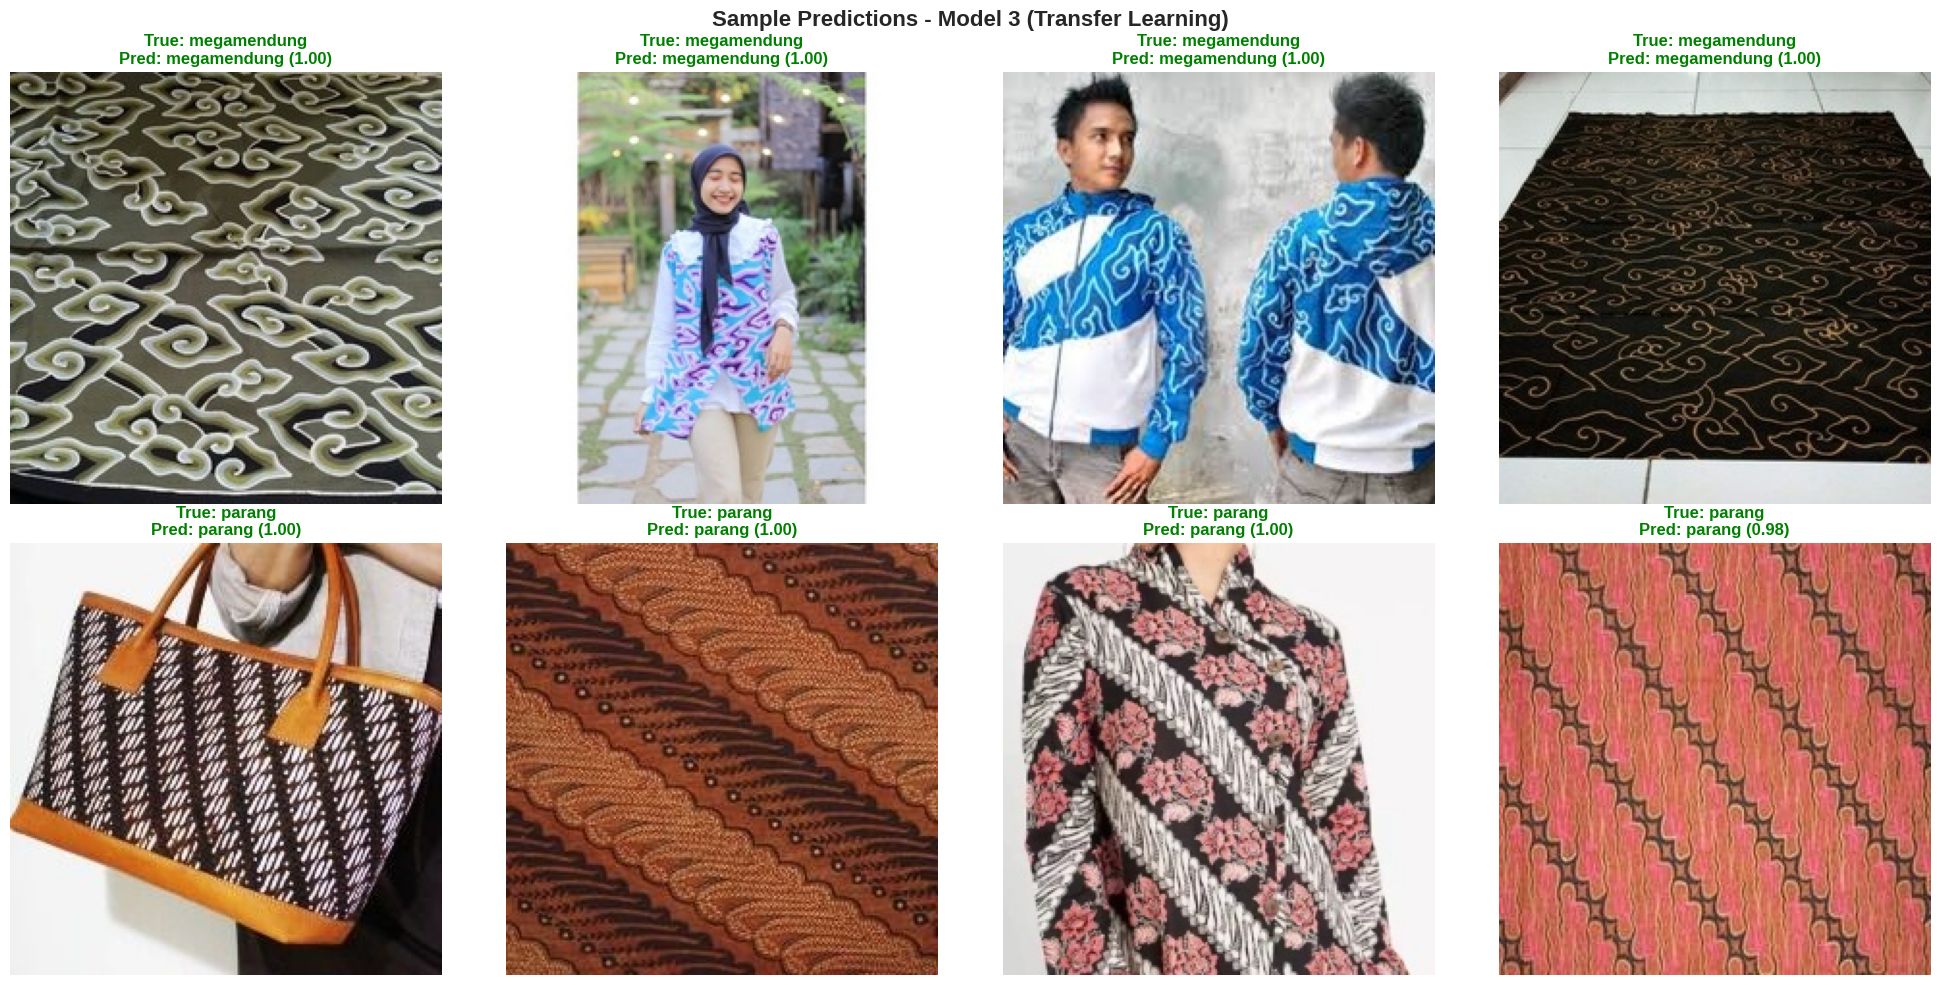

In [ ]:
# Visualisasi sample predictions dengan confidence scores
def show_predictions_with_confidence(model, model_name, test_path, num_samples=8):
    """Menampilkan sample predictions dengan confidence scores"""
    fig, axes = plt.subplots(2, num_samples//2, figsize=(20, 10))
    axes = axes.flatten()

    # Ambil sample gambar dari test set
    sample_images = []
    true_labels = []

    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(test_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Ambil 4 sample dari setiap kelas
        sample_files = np.random.choice(image_files, num_samples//2, replace=False)

        for filename in sample_files:
            img_path = os.path.join(class_path, filename)
            img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            sample_images.append(img)
            true_labels.append(class_name)

    # Preprocess images for prediction
    processed_images = []
    for img in sample_images:
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0
        processed_images.append(img_array[0])

    batch_images = np.array(processed_images)

    # Make predictions
    predictions = model.predict(batch_images, verbose=0)

    # Plot results
    for i in range(num_samples):
        axes[i].imshow(sample_images[i])

        # Get prediction
        pred_probs = predictions[i]
        pred_class_idx = np.argmax(pred_probs)
        pred_class = CLASS_NAMES[pred_class_idx]
        confidence = pred_probs[pred_class_idx]

        # True label
        true_class = true_labels[i]

        # Color: green if correct, red if incorrect
        color = 'green' if pred_class == true_class else 'red'

        # Title with prediction info
        title = f'True: {true_class}\nPred: {pred_class} ({confidence:.2f})'
        axes[i].set_title(title, fontweight='bold', color=color)
        axes[i].axis('off')

    plt.suptitle(f'Sample Predictions - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Tampilkan predictions untuk model terbaik (misal Model 3)
print("Sample Predictions dengan Confidence Scores:")
show_predictions_with_confidence(model_3, 'Model 3 (Transfer Learning)', test_path)

Contoh prediksi di atas menunjukkan bahwa **Model 3 (Transfer Learning – MobileNetV2) mampu mengenali motif megamendung dan parang dengan sangat akurat**, bahkan pada gambar dengan konteks berbeda seperti pakaian, tas, dan foto manusia yang mengenakan batik. Semua contoh ditampilkan dengan **confidence score yang sangat tinggi (mendekati 1.00)**, menandakan bahwa model **sangat yakin** terhadap prediksinya.

Keberhasilan ini menunjukkan bahwa **fitur pretrained MobileNetV2 mampu menangkap pola tekstur dan garis khas** pada kedua motif, meskipun muncul dalam kondisi dunia nyata yang bervariasi—mulai dari **pencahayaan**, **latar belakang**, **orientasi gambar**, hingga **gaya fotografi**. Konsistensi prediksi pada berbagai jenis media membuktikan bahwa **Model 3 memiliki kemampuan generalisasi yang sangat kuat** dan bekerja dengan baik tidak hanya pada data uji terstruktur, tetapi juga pada **skenario dunia nyata**.


## Kesimpulan

Berdasarkan seluruh rangkaian eksperimen, dapat disimpulkan bahwa **penggunaan transfer learning dengan MobileNetV2 memberikan peningkatan performa yang sangat signifikan** dibanding CNN sederhana yang dilatih dari nol. Dengan jumlah data yang terbatas, **fitur pretrained mampu mengekstraksi tekstur dan pola batik secara jauh lebih efektif**, menghasilkan **akurasi, loss, dan macro-F1 yang jauh lebih unggul**. Evaluasi pada data uji serta contoh prediksi juga menunjukkan bahwa model memiliki **kemampuan generalisasi yang kuat** di berbagai kondisi gambar dunia nyata. Secara keseluruhan, **Model 3 merupakan pendekatan yang paling tepat dan andal** untuk tugas klasifikasi motif batik pada dataset ini.
